# Introduction to Scikit Learn(SK learn)

This notebook demonstrates some of the most useful functions of scikit-learn library

what we are going to cover:-
1. End-to-end scikit learn workflow
2. Getting data Ready
3. Choose the right estimator/algorithm for our problem
4. fit the model and use it to mak prediction
5. Evaluate the model
6. impoive a model
7. Save and load a trained model
8. Putting it all together

## 1. End-to-End scikit learn workflow

In [245]:
# 1. get the data ready
import pandas as pd
heart_diease = pd.read_csv("heart_disease.csv")
heart_diease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [246]:
# create x(feature matrix)
X = heart_diease.drop("target",axis=1)

# create Y (label matrix)
Y = heart_diease["target"]

In [247]:
# 2. choose the right model and hyper parameter
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

# we'll keep the default hyper paramters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [248]:
# 3 fit the model to the training data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

In [249]:
# fit the model
clf.fit(x_train,y_train);

In [250]:
# make a prediction
y_labels = clf.predict(x_test)

In [251]:
y_labels

array([1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1])

In [252]:
y_test

28     1
159    1
78     1
237    0
13     1
      ..
213    0
61     1
102    1
91     1
39     1
Name: target, Length: 61, dtype: int64

In [253]:
# 4. Evaluate the model on training and test data
clf.score(x_train,y_train)

1.0

In [254]:
clf.score(x_test,y_test)

0.8688524590163934

In [255]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_labels))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        30
           1       0.85      0.90      0.88        31

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [256]:
confusion_matrix(y_test,y_labels)

array([[25,  5],
       [ 3, 28]])

In [257]:
accuracy_score(y_test,y_labels)

0.8688524590163934

In [258]:
# 5. Imporove a model
# Try different amount of hyper parameters
import numpy as np
np.random.seed(42)
for i in range(10,150,10):
    print(f"Trying models with {i} estimators.....")
    clf = RandomForestClassifier(n_estimators=i)
    clf.fit(x_train,y_train)
    print(f"Model Accuracy on test Sets: {clf.score(x_test,y_test)*100:.2f}%")
    print("")

Trying models with 10 estimators.....
Model Accuracy on test Sets: 85.25%

Trying models with 20 estimators.....
Model Accuracy on test Sets: 80.33%

Trying models with 30 estimators.....
Model Accuracy on test Sets: 85.25%

Trying models with 40 estimators.....
Model Accuracy on test Sets: 85.25%

Trying models with 50 estimators.....
Model Accuracy on test Sets: 81.97%

Trying models with 60 estimators.....
Model Accuracy on test Sets: 86.89%

Trying models with 70 estimators.....
Model Accuracy on test Sets: 85.25%

Trying models with 80 estimators.....
Model Accuracy on test Sets: 86.89%

Trying models with 90 estimators.....
Model Accuracy on test Sets: 85.25%

Trying models with 100 estimators.....
Model Accuracy on test Sets: 86.89%

Trying models with 110 estimators.....
Model Accuracy on test Sets: 86.89%

Trying models with 120 estimators.....
Model Accuracy on test Sets: 85.25%

Trying models with 130 estimators.....
Model Accuracy on test Sets: 83.61%

Trying models with 14

In [259]:
# 6. Save a model and load it
import pickle

pickle.dump(clf, open("Random-forest-model-1.pkl","wb"))

C:\Users\Savya Sapkota\AppData\Local\Temp\ipykernel_11968\1877534851.py:4: ResourceWarning: unclosed file <_io.BufferedWriter name='Random-forest-model-1.pkl'>
  pickle.dump(clf, open("Random-forest-model-1.pkl","wb"))


In [260]:
loaded_model = pickle.load(open("Random-forest-model-1.pkl","rb"))
loaded_model.score(x_test,y_test)

C:\Users\Savya Sapkota\AppData\Local\Temp\ipykernel_11968\3502958611.py:1: ResourceWarning: unclosed file <_io.BufferedReader name='Random-forest-model-1.pkl'>
  loaded_model = pickle.load(open("Random-forest-model-1.pkl","rb"))


0.8524590163934426

In [261]:
# to ignore the wornings
import warnings
warnings.filterwarnings("default") # default, ignore

In [262]:
import sklearn
sklearn.show_versions()


System:
    python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
executable: C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\python.exe
   machine: Windows-10-10.0.19045-SP0

Python dependencies:
      sklearn: 1.8.0
          pip: 25.3
   setuptools: 80.9.0
        numpy: 2.3.5
        scipy: 1.16.3
       Cython: None
       pandas: 2.3.3
   matplotlib: 3.10.7
       joblib: 1.5.2
threadpoolctl: 3.5.0

Built with OpenMP: True

threadpoolctl info:
       user_api: blas
   internal_api: mkl
    num_threads: 2
         prefix: mkl_rt
       filepath: C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Library\bin\mkl_rt.2.dll
        version: 2025.0-Product
threading_layer: intel

       user_api: openmp
   internal_api: openmp
    num_threads: 4
         prefix: libiomp
       filepath: C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Library\bin\libiomp5md.d

In [263]:
what_we_are_going_to_cover = [
"0. End-to-end scikit learn workflow",
"1. Getting data Ready",
"2. Choose the right estimator/algorithm for our problem",
"3. fit the model and use it to mak prediction",
"4. impoive a model",
"5. Save and load a trained model",
"6. Putting it all together"
]

In [264]:
what_we_are_going_to_cover


['0. End-to-end scikit learn workflow',
 '1. Getting data Ready',
 '2. Choose the right estimator/algorithm for our problem',
 '3. fit the model and use it to mak prediction',
 '4. impoive a model',
 '5. Save and load a trained model',
 '6. Putting it all together']

In [265]:
# standaret imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [266]:
## 1. Getting our data ready to be used with machine learning
heart_diease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [267]:
X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]
X.head(),Y.head()

(   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
 0   63    1   3       145   233    1        0      150      0      2.3      0   
 1   37    1   2       130   250    0        1      187      0      3.5      0   
 2   41    0   1       130   204    0        0      172      0      1.4      2   
 3   56    1   1       120   236    0        1      178      0      0.8      2   
 4   57    0   0       120   354    0        1      163      1      0.6      2   
 
    ca  thal  
 0   0     1  
 1   0     2  
 2   0     2  
 3   0     2  
 4   0     2  ,
 0    1
 1    1
 2    1
 3    1
 4    1
 Name: target, dtype: int64)

In [268]:
# split the data into train and test sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

In [269]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [270]:
X.shape,Y.shape

((303, 13), (303,))

In [271]:
heart_diease.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

# 1.1 Make Sure its all numerical

In [272]:
car_sales = pd.read_csv("car-sales-extended.csv")
len(car_sales)

1000

In [273]:
car_sales.head()


,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [274]:
car_sales.dtypes


Make             object
Colour           object
Odometer (KM)     int64
Doors             int64
Price             int64
dtype: object

In [275]:
# split the data into X and Y
X = car_sales.drop("Price",axis=1)
Y = car_sales["Price"]

In [276]:
# split the data into train and test split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)


In [277]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestClassifier()

In [278]:
model.fit(x_train,y_train)

ValueError: could not convert string to float: 'Nissan'

In [279]:
X

,Make,Colour,Odometer (KM),Doors
0,Honda,White,35431,4
1,BMW,Blue,192714,5
2,Honda,White,84714,4
3,Toyota,White,154365,4
4,Nissan,Blue,181577,3
...,...,...,...,...
995,Toyota,Black,35820,4
996,Nissan,White,155144,3
997,Nissan,Blue,66604,4
998,Honda,White,215883,4


In [280]:
# Convert string into numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")

transformed_x = transformer.fit_transform(X)
transformed_x

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(1000, 13))

In [281]:
pd.DataFrame(transformed_x)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [282]:
# using pandas
dummies = pd.get_dummies(car_sales[["Make","Colour","Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


In [283]:
np.random.seed(42)
x_train,x_test,y_train,y_test = train_test_split(transformed_x,Y,test_size=0.2)


In [284]:
model = RandomForestRegressor()

In [285]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [286]:
model.score(x_test,y_test)

0.3235867221569877

### 1.2 Dealing with missing values

1. Fill them with some values (Imputation).
2. Remove the samples with missing data altogether.

In [287]:
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")

In [288]:
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [289]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [290]:
# lets split the data into X and Y(features and labels)
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing["Price"]

In [291]:
# lets try and convert out data to numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")
transformed_x = transformer.fit_transform(X)
transformed_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4000 stored elements and shape (1000, 16)>

### Option 1: Dealing with missing values using Pandas

In [292]:
# fill the make column
car_sales_missing["Make"] = car_sales_missing["Make"].fillna("Missing")

# fill the colour column
car_sales_missing["Colour"] = car_sales_missing["Colour"].fillna("Missing")

# fill the odometer column
car_sales_missing["Odometer (KM)"] = car_sales_missing["Odometer (KM)"].fillna(car_sales_missing["Odometer (KM)"].mean())

# fill the door columns
car_sales_missing["Doors"] = car_sales_missing["Doors"].fillna(4)


In [293]:
car_sales_missing.isna().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [294]:
# lets not fill price column insted lets remove it
car_sales_missing = car_sales_missing.dropna()

In [295]:
car_sales_missing.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [296]:
len(car_sales_missing)

950

In [297]:
# lets split the data into X and Y(features and labels)
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing["Price"]

In [298]:
# lets try and convert out data to numbers
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,categorical_features)],remainder="passthrough")
transformed_x = transformer.fit_transform(car_sales_missing)
transformed_x

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]], shape=(950, 16))

In [299]:
pd.DataFrame(transformed_x)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0,15323.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0,19943.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0,28343.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0,13434.0
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0,14043.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0,32042.0
946,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0,5716.0
947,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0,31570.0
948,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0,4001.0


### Option 2: Fill missing values with scikit learn

In [300]:
car_sales_missing = pd.read_csv("car-sales-extended-missing-data.csv")
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [301]:
# lets remove rows with price values
car_sales_missing = car_sales_missing.dropna(subset=["Price"])
car_sales_missing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [302]:
# split the data into x and y
X = car_sales_missing.drop("Price",axis=1)
Y = car_sales_missing["Price"]

In [303]:
# fill missing value with sklearn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# fill categirical values with 'missing' and numerical with 'mean'
cat_imputer = SimpleImputer(strategy="constant",fill_value="missing")
door_imputer = SimpleImputer(strategy="constant",fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

# define columns
cat_features = ["Make","Colour"]
door_features = ["Doors"]
num_feature = ["Odometer (KM)"]


# create an imputer
imputer = ColumnTransformer([("cat_imputer",cat_imputer,cat_features),("door_imputer",door_imputer,door_features),("num_imputer",num_imputer,num_feature)])

# Transform the data
filled_x = imputer.fit_transform(X)
filled_x

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

In [304]:
car_slaes_filled = pd.DataFrame(filled_x,columns=["Make","Colour","Doors","Odometer (KM)"])
car_slaes_filled.head()

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0


In [305]:
car_slaes_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [306]:
# we have already seperated price as y so lets convert it into numeric values
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_features = ["Make","Colour","Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",one_hot,cat_features)],remainder="passthrough")
trnasformed_x = transformer.fit_transform(car_slaes_filled)
transformed_x


array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]], shape=(950, 16))

In [307]:
# conver into train test split
np.random.seed(42)
model = RandomForestRegressor()
x_train,x_test,y_train,y_test = train_test_split(transformed_x,Y,test_size=0.2)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [308]:
model.score(x_test,y_test)

0.9998779571775143

## 2. Choosing the right estimator/algorithm for your problem
Some things to note

* Sklearn refers machine learning model/algorithm as estimators.
* Classification problem - predicing category 0 or 1 (clf short for classifier)
* Regression Problem - predicting a number such as selling price of a car

### Picking a machine learning model for a regression problem

Let's use the california housing datasets

In [309]:
# Get the cali housing dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [310]:
housing_df = pd.DataFrame(housing["data"],columns=housing["feature_names"])

In [311]:
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [312]:
housing_df["target"] = housing["target"]
housing_df = housing_df.drop("MedHouseVal",axis=1)

KeyError: "['MedHouseVal'] not found in axis"

In [ ]:
housing_df

In [313]:
housing_df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [314]:
housing_df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object

In [315]:
# Import Algorithm

# setup random seed
np.random.seed(42)

# create the data
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

# split the data into train and test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# instianciate and fit the model
from sklearn.linear_model import Ridge
model = Ridge()
model.fit(x_train,y_train)

# check the score on the test set
model.score(x_test,y_test)


0.5758549611440126

In [316]:
# lets try SVM
from sklearn.svm import SVR
model = SVR()
model.fit(x_train,y_train)
model.score(x_test,y_test)

-0.01648536010717705

In [317]:
# lets try another (Lasso)
from sklearn.linear_model import Lasso
model  = Lasso()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.2841671821008396

In [318]:
# lets try random forest regressor from ensemble model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.806713773302341

In [319]:
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [320]:
# full workflow
# import the model/estimator
from sklearn.ensemble import RandomForestRegressor

# create a random seed
np.random.seed(42)

# split the data into X anf Y (feature and label matrix)
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

# split the data into train and test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# instianciate the model
model = RandomForestRegressor()

# fit the model
model.fit(x_train,y_train)

# Evaluate the model
model.score(x_test,y_test)

0.8065734772187598

## 2.2 Picking a model for classification problem

In [321]:
heart_diease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [322]:
len(heart_diease)

303

In [323]:
# import linear svc
from sklearn.svm import LinearSVC
# setup random seed
np.random.seed(42)

# split the data into X and Y
X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

# split the data into train and test split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# instiancate the model
clf = LinearSVC()

# fit the model
clf.fit(x_train,y_train)

# Evaluate the model
clf.score(x_test,y_test)


0.8688524590163934

In [324]:
clf.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': 'auto',
 'fit_intercept': True,
 'intercept_scaling': 1,
 'loss': 'squared_hinge',
 'max_iter': 1000,
 'multi_class': 'ovr',
 'penalty': 'l2',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [325]:
# lets try ensemble methods
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.fit(x_train,y_train)

clf.score(x_test,y_test)

0.8524590163934426

## 3. Fit the model and make predictions

### 3.1 fitting the model to the data

Different Names for:

* 'X' = features, Freture Variables, data
* 'Y' = labels, targets, target variables

In [326]:
# import linear svc
from sklearn.ensemble import RandomForestClassifier
# setup random seed
np.random.seed(42)

# split the data into X and Y
X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

# split the data into train and test split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

# instiancate the model
clf = RandomForestClassifier()

# fit the model to the data
clf.fit(x_train,y_train)

# Evaluate the model
clf.score(x_test,y_test)


0.8524590163934426

In [327]:
X.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [328]:
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

### 3.2 Make predictions using machine learning model

2 ways to make a prediction
1. use Predict function
2. predict_proba()

In [329]:
clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [330]:
# use a trained model to make predictions
clf.predict(x_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [331]:
 np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [332]:
# compare predictions to truth label to evaluate the model
y_preds = clf.predict(x_test)
np.mean(y_preds == y_test)

np.float64(0.8524590163934426)

In [333]:
clf.score(x_test,y_test)

0.8524590163934426

In [334]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_preds)

0.8524590163934426

# Make prediction with preduct proba

## predict probe return probasbilities of classification labels

In [335]:
clf.predict_proba(x_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [336]:
#lets predict on the same data
clf.predict(x_test[:5])

array([0, 1, 1, 0, 1])

# 'Predict()' can also be used for regression datasets

In [337]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [338]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestRegressor()

model.fit(x_train,y_train)

y_preds = model.predict(x_test)

y_preds[:10]

array([0.49384  , 0.75494  , 4.9285964, 2.54316  , 2.33176  , 1.6525301,
       2.34323  , 1.66182  , 2.47489  , 4.8344779])

In [339]:
y_preds[:10]

array([0.49384  , 0.75494  , 4.9285964, 2.54316  , 2.33176  , 1.6525301,
       2.34323  , 1.66182  , 2.47489  , 4.8344779])

In [340]:
np.array(y_test[:10])

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

In [341]:
len(y_preds), len(y_test)

(4128, 4128)

In [342]:
# average diffrernce between actual and predicted values
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_preds)


0.32659871732073664

In [343]:
housing_df_preds = model.predict(x_test)

In [344]:
housing_df_target = housing_df["target"]

In [345]:
housing_df_preds

array([0.49384  , 0.75494  , 4.9285964, ..., 4.8363785, 0.71782  ,
       1.67901  ], shape=(4128,))

In [346]:
housing_df_target

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: target, Length: 20640, dtype: float64

In [347]:
what_we_are_going_to_cover = ['0. End-to-end scikit learn workflow',
 '1. Getting data Ready',
 '2. Choose the right estimator/algorithm for our problem',
 '3. fit the model and use it to mak prediction',
 '4. Evaluate the model'                            
 '5. improve a model',
 '6. Save and load a trained model',
 '7. Putting it all together']

In [348]:
what_we_are_going_to_cover

['0. End-to-end scikit learn workflow',
 '1. Getting data Ready',
 '2. Choose the right estimator/algorithm for our problem',
 '3. fit the model and use it to mak prediction',
 '4. Evaluate the model5. improve a model',
 '6. Save and load a trained model',
 '7. Putting it all together']

## 4. Evaluate a machin learning model

There are three inbuilt ways to evaluate the models
1. using built-in `Score()` Parameter
2. The `scoring()` parameter
3. Problem-specific metric functions

## 4.1 Evaluating a model with a `Score` method

In [349]:
# using Score method
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

clf = RandomForestClassifier()

clf.fit(x_train,y_train)

clf.score(x_test,y_test)

0.8524590163934426

In [350]:
# The higest value for score method is 1.0 and lowest in 0.0
## something is fishy!!! ahh it is using training data to test it.
clf.score(x_train,y_train)

1.0

# lets use the `score()` on regression

In [351]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestRegressor()

model.fit(x_train,y_train)

model.score(x_test,y_test)

0.8065734772187598

## 4.2 Evaluating the model using `scoring()` parameter

In [352]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

clf = RandomForestClassifier()

clf.fit(x_train,y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [353]:
clf.score(x_test,y_test)

0.8524590163934426

In [354]:
cross_val_score(clf,X,Y)

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

![](Cross_validation.png)

In [355]:
cross_val_score(clf,X,Y)


array([0.83606557, 0.8852459 , 0.7704918 , 0.8       , 0.8       ])

In [356]:
cross_val_score(clf,X,Y, cv = 10)

array([0.90322581, 0.83870968, 0.87096774, 0.9       , 0.86666667,
       0.8       , 0.76666667, 0.83333333, 0.73333333, 0.83333333])

In [357]:
np.random.seed(42)

# single training and test split score
clf_single_score = clf.score(x_test,y_test)

# take a mean of five fold cross val score
clf_cross_val_score = np.mean(cross_val_score(clf,X,Y))

# compare the two
clf_cross_val_score,clf_single_score

(np.float64(0.8248087431693989), 0.8524590163934426)

In [358]:
# default scoring parameter of classifier = mean accuracy
clf.score(x_test,y_test)

0.8524590163934426

In [359]:
# scoring parameter is set to None by default (mean accuracy)
cross_val_score(clf,X,Y,scoring=None)

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

### 4.2.1 Classification model evaluation metrics
1. Accuracy
2. Area uner ROC curve
3. COnfusion matrix
4. classification report

## 1. Accuracy

In [360]:
heart_diease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [361]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

clf = RandomForestClassifier()

cross_val_score = cross_val_score(clf,X,Y)

In [362]:
np.mean(cross_val_score)

np.float64(0.8248087431693989)

In [363]:
print(f"Heart Disease Classifier Accuracy: {np.mean(cross_val_score)* 100:.2f}%")

Heart Disease Classifier Accuracy: 82.48%


## Area under the ROC(Receiver Operating Characterstic curve)Curve(AUC/ROC Curve)
* Area Under Curve(AUC)
* ROC Curve

ROC curves are the comparision between models (TPR) and False POsitive rate (FPR)


In [364]:
#create X_test
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)
clf = RandomForestClassifier()
clf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [365]:
from sklearn.metrics import roc_curve

y_preds = clf.predict_proba(x_test)

y_preds[:10]


array([[0.51, 0.49],
       [0.17, 0.83],
       [0.51, 0.49],
       [0.72, 0.28],
       [0.43, 0.57],
       [0.12, 0.88],
       [0.3 , 0.7 ],
       [0.97, 0.03],
       [0.15, 0.85],
       [0.4 , 0.6 ]])

In [366]:
# probabilities of positive or 1 because it is comparision of true positive vs false positive got it positive positive(0: negative,1 :positive)
y_probs_positive = y_preds[:,1]
y_probs_positive[:10]

array([0.49, 0.83, 0.49, 0.28, 0.57, 0.88, 0.7 , 0.03, 0.85, 0.6 ])

In [367]:
# we can calculate fpr,tpr and threshold
fpr,tpr,threshold = roc_curve(y_test,y_probs_positive)

# check the false positive rates
fpr

array([0.        , 0.03448276, 0.03448276, 0.03448276, 0.03448276,
       0.03448276, 0.03448276, 0.06896552, 0.06896552, 0.06896552,
       0.10344828, 0.10344828, 0.13793103, 0.13793103, 0.13793103,
       0.20689655, 0.20689655, 0.20689655, 0.27586207, 0.37931034,
       0.37931034, 0.48275862, 0.48275862, 0.55172414, 0.55172414,
       1.        ])

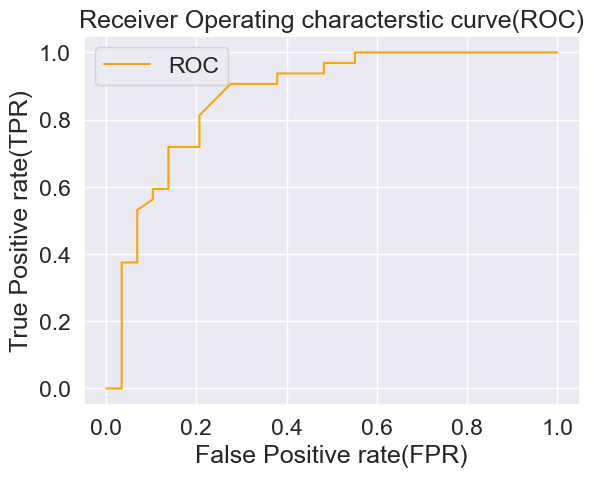

In [368]:
# create a function to plot a roc_curve
import matplotlib.pyplot as plt

def plot_roc_curve(frp,tpr):
    """
    Plots Roc curve given the false positive rate fpr and true positive rate tpr
    """

    # plot toc curve
    plt.plot(fpr,tpr,color="orange",label="ROC")

    # plot line with no predective power(baseline)
    # plt.plot([0,1],[0,1],color="darkblue",linestyle="--",label="Guessing")

    # customize the plot
    plt.xlabel("False Positive rate(FPR)")
    plt.ylabel("True Positive rate(TPR)")
    plt.title("Receiver Operating characterstic curve(ROC)")
    plt.legend()
plot_roc_curve(fpr,tpr)

In [369]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_probs_positive)


0.8669181034482759

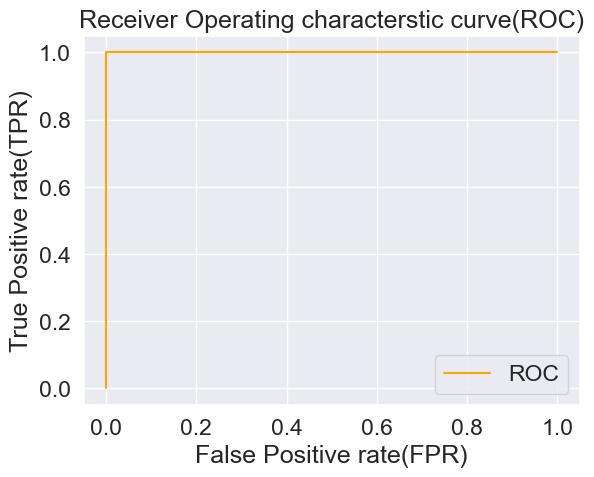

In [370]:
# lets see the perfect roc curve and auc score
fpr,tpr,threshold = roc_curve(y_test,y_test)
plot_roc_curve(fpr,tpr)

In [371]:
# perfect auc score 
roc_auc_score(y_test,y_test)

1.0

## Lets try confustion matrix

In [372]:
from sklearn.metrics import confusion_matrix
y_preds = clf.predict(x_test)

confusion_matrix(y_test,y_preds)

array([[23,  6],
       [ 6, 26]])

In [373]:
# visualide the confusion matrix with pd cross tab
pd.crosstab(y_test,y_preds,rownames = ["Actual Labels"],colnames=["Predicted Labels"])

Predicted Labels,0,1
Actual Labels,,
0,23,6
1,6,26


![](confusion_matrix.png)

In [374]:
#to install conda package frim jupter
# import sys
# !conda install --yes --prefix {sys.prefix} seaborn

<Axes: >

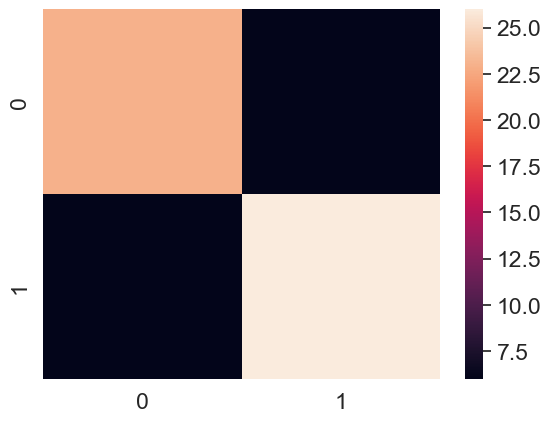

In [375]:
# make our confusion matrix more visual with seaborn heatmap
import seaborn as sns

# set the font scale
sns.set(font_scale=1.5)

conf_mat = confusion_matrix(y_test,y_preds)

sns.heatmap(conf_mat)

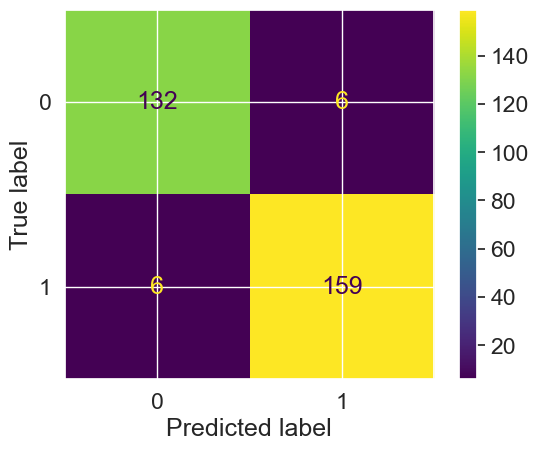

In [376]:
# this is from estimator
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(estimator=clf,X=X,y= Y)

In [377]:
len(heart_diease)

303

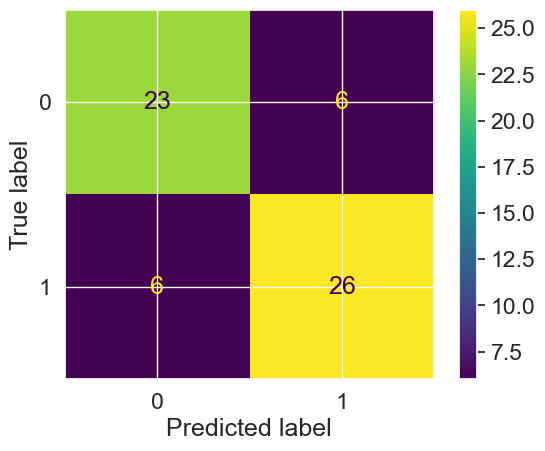

In [378]:
# this is from prediction
ConfusionMatrixDisplay.from_predictions(y_test,y_preds)

## Calssification report

In [379]:
from sklearn.metrics import classification_report
classification_report(y_test,y_preds)

'              precision    recall  f1-score   support\n\n           0       0.79      0.79      0.79        29\n           1       0.81      0.81      0.81        32\n\n    accuracy                           0.80        61\n   macro avg       0.80      0.80      0.80        61\nweighted avg       0.80      0.80      0.80        61\n'

In [380]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        29
           1       0.81      0.81      0.81        32

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



![](classification-report.png)

In [381]:
# where precision and recall become valuable
disease_true = np.zeros(1000)
disease_true[0] = 1

In [382]:
disease_preds = np.zeros(1000)

pd.DataFrame(classification_report(disease_true,disease_preds,output_dict=True))

C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Savya Sapkota\Desktop\Machine_learning\Heart_Disease_Analysis\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.9990,0.0,0.999,0.49950,0.998001
recall,1.0000,0.0,0.999,0.50000,0.999000
f1-score,0.9995,0.0,0.999,0.49975,0.998500
support,999.0000,1.0,0.999,1000.00000,1000.000000


### 4.2.2 Regression model evaluation 

The ones that we are going to cover are
1. R^2 (r-squared)
2. Mean Absolute Error(MAE)
3. Mean Squared Error(MSE)

In [383]:
housing_df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')

In [384]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestRegressor()

model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [385]:
model.score(x_test,y_test)

0.8065734772187598

In [386]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

In [387]:
y_test.mean()

np.float64(2.0550030959302323)

In [388]:
from sklearn.metrics import r2_score
y_test_mean = np.full(len(y_test),y_test.mean())

In [389]:
y_test_mean[:10]

array([2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031,
       2.0550031, 2.0550031, 2.0550031, 2.0550031])

In [390]:
r2_score(y_test,y_test_mean)

0.0

In [391]:
r2_score(y_test,y_test)

1.0

In [392]:
y_preds = model.predict(x_test)

In [393]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mean_squared_error(y_test,y_preds)

0.2534678520824551

In [394]:
mean_absolute_error(y_test,y_preds)

0.32659871732073664

** Mean Absolute Error(MAE) **

MAE is the average of the absolute differences between predictions and actual values

IT gives you an idea of how wrong your models predictions are


In [395]:
from sklearn.metrics import mean_absolute_error

y_preds = model.predict(x_test)

mae = mean_absolute_error(y_test,y_preds)
mae

0.32659871732073664

In [396]:
y_preds

array([0.49384  , 0.75494  , 4.9285964, ..., 4.8363785, 0.71782  ,
       1.67901  ], shape=(4128,))

In [397]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

In [398]:
df = pd.DataFrame(data={"actual_values":y_test,"predicted_values":y_preds})
df["difference"] = df["predicted_values"] - df["actual_values"]
df.head(10)

,actual_values,predicted_values,difference
20046,0.47700,0.493840,0.016840
3024,0.45800,0.754940,0.296940
15663,5.00001,4.928596,-0.071414
20484,2.18600,2.543160,0.357160
9814,2.78000,2.331760,-0.448240
13311,1.58700,1.652530,0.065530
7113,1.98200,2.343230,0.361230
7668,1.57500,1.661820,0.086820
18246,3.40000,2.474890,-0.925110
5723,4.46600,4.834478,0.368478


In [399]:
df["difference"].mean()

np.float64(0.012048392126937589)

In [400]:
# calculating mea using formula
np.abs(df["difference"]).mean()

np.float64(0.32659871732073664)

**Mean Squared Error(MSE)**
MSE is the mean of the square of the errors between actual and prdicted values.

In [401]:
# Mean squared error
from sklearn.metrics import mean_squared_error
y_preds - model.predict(x_test)

mse = mean_squared_error(y_test,y_preds)

mse

0.2534678520824551

In [402]:
df["squared_diff"] = np.square(df["difference"])

In [403]:
df.head()

,actual_values,predicted_values,difference,squared_diff
20046,0.47700,0.493840,0.016840,0.000284
3024,0.45800,0.754940,0.296940,0.088173
15663,5.00001,4.928596,-0.071414,0.005100
20484,2.18600,2.543160,0.357160,0.127563
9814,2.78000,2.331760,-0.448240,0.200919


In [404]:
np.mean(df["squared_diff"])

np.float64(0.2534678520824551)

# Finally using the scoring parameter

In [405]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

clf = RandomForestClassifier()


In [406]:
np.random.seed(42)

# cross validation accuracy
cv_acc = cross_val_score(clf,X,Y,scoring=None)
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [407]:
np.mean(cv_acc)

np.float64(0.8248087431693989)

In [408]:
# cross validates accuract
print(f"The cross validates accuracy is {np.mean(cv_acc)*100:.2f}%")

The cross validates accuracy is 82.48%


In [409]:
np.random.seed(42)
cv_acc = cross_val_score(clf,X,Y,scoring="accuracy")
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [410]:
# Corss validates accuracy
print(f"The cross validates accuracy is {np.mean(cv_acc)*100:.2f}%")

The cross validates accuracy is 82.48%


In [411]:
# precision
np.random.seed(42)

cv_acc = cross_val_score(clf,X,Y,scoring="precision")
cv_acc

array([0.82352941, 0.93548387, 0.84848485, 0.79411765, 0.76315789])

In [412]:
# Corss validated precision
print(f"The cross validated precision score is {np.mean(cv_acc)}")

The cross validated precision score is 0.8329547346025924


In [413]:
# recall
np.random.seed(42)
cv_recall = cross_val_score(clf,X,Y,scoring="recall")
cv_recall

array([0.84848485, 0.87878788, 0.84848485, 0.81818182, 0.87878788])

In [414]:
# Corss validated recall
print(f"The cross validated recall score is {np.mean(cv_recall)}")

The cross validated recall score is 0.8545454545454545


# let's see the scoring parameer being used for regression problem

In [415]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [416]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
np.random.seed(42)
X = housing_df.drop("target",axis=1)
Y = housing_df["target"]


model = RandomForestRegressor()

model_coef = cross_val_score(model,X,Y)

model_coef


array([0.51682388, 0.70279716, 0.74197717, 0.61638204, 0.68243183])

In [417]:
print(f"The coefficient of determonation or r^2 is {np.mean(model_coef)}")

The coefficient of determonation or r^2 is 0.6520824166120266


In [418]:
# using negative_mean_absolute error
np.random.seed(42)
model_neg_mae = cross_val_score(model,X,Y,scoring="neg_mean_absolute_error")
model_neg_mae

array([-0.54256026, -0.40902123, -0.43706982, -0.46918522, -0.47318856])

In [419]:
print(f"The negative mean abs error is {np.mean(model_neg_mae)}")

The negative mean abs error is -0.46620501732073655


In [420]:
# using negative_mean_squared error
np.random.seed(42)
model_neg_mse = cross_val_score(model,X,Y,scoring="neg_mean_squared_error")
model_neg_mse

array([-0.51906271, -0.34789469, -0.37117373, -0.4500546 , -0.46274716])

In [421]:
print(f"The negative mean squared error is {np.mean(model_neg_mse)}")

The negative mean squared error is -0.4301865790173885


## 4.3 Using different evaluation metrics as Scikit-Learn functions

THe 3rd way to evaluate scikit-learning machine learning models/estimtors is to using  the sklearn.metrics 

In [422]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X = heart_diease.drop("target",axis=1)
Y = heart_diease["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

clf = RandomForestClassifier()

clf.fit(x_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [423]:
y_preds = clf.predict(x_test)

In [424]:
accuracy = accuracy_score(y_test,y_preds)
precision = precision_score(y_test,y_preds)
recall = recall_score(y_test,y_preds)
f1 = f1_score(y_test,y_preds)

print(f"The accuracy score is:- {accuracy*100:.2f}% \nThe Precision Score is:-{precision}\nTHe Recall Score is:- {recall}\nThe F1 Score is:- {f1}")

The accuracy score is:- 85.25% 
The Precision Score is:-0.8484848484848485
THe Recall Score is:- 0.875
The F1 Score is:- 0.8615384615384616


In [425]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = housing_df.drop("target",axis=1)
Y = housing_df["target"]

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

model = RandomForestRegressor()

model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [426]:
y_preds = model.predict(x_test)

In [427]:
r2 = r2_score(y_test,y_preds)
mae = mean_absolute_error(y_test,y_preds)
mse = mean_squared_error(y_test,y_preds)

r2,mae,mse

(0.8065734772187598, 0.32659871732073664, 0.2534678520824551)

In [428]:
print(f"The R^2 score is:- {r2}\nThe Mean Absolute Error Score is:- {mae}\nTHe Mean Squared Error Score is:- {mse}")

The R^2 score is:- 0.8065734772187598
The Mean Absolute Error Score is:- 0.32659871732073664
THe Mean Squared Error Score is:- 0.2534678520824551


## 5. Improving a modeel

First predictions = Baseline predcictions
First Model = Baseline Model

1. Improving from data prospective
    * Can we collect more data? (generally, the more data, the better)
    * Can we improve our data?
      

2. From Model Prospective
    * Is there a better model that can be used?
    * Could we improve the current model?

### Parameters = Patterns found by model on data
### Hyperparameters = settings on the model that you can adjust to imprive the model


   


In [432]:
# TO CHECK HYPERPARAMETERS
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

## 5.1 Tuning hyper parameters by hand

![](tuning.png)

Lets make three sets(training,validation and test)

In [433]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

we are going to adjust the following hyperparametered :-

* `max_depth`
* `max_featueres`
* `min_sample_leaf`
* `min_sample_split`
* `n_estimators`


In [448]:
 def evaluate_preds(y_true,y_preds):
     """
     performs evaluation comparision on y_true labels vs y_preds labels.
     on our classification model
     """
     accuracy = accuracy_score(y_true,y_preds)
     precision = precision_score(y_true,y_preds)
     recall = recall_score(y_true,y_preds)
     f1 = f1_score(y_true,y_preds)
     metric_dict = {"accuracy":round(accuracy,2),
                   "precision":round(precision,2),
                   "recall":round(recall,2),
                   "f1":round(f1,2)}
     print(f"Accuracy Score: {accuracy*100:.2f}%")
     print(f"Precision Score: {precision:.2f}")
     print(f"Recall Score: {recall:.2f}")
     print(f"F1 Score: {f1:.2f}")

     return metric_dict
     

In [449]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

heart_diease_shuffeled = heart_diease.sample(frac=1)

# split into X and Y
X = heart_diease_shuffeled.drop("target",axis=1)
Y = heart_diease_shuffeled["target"]

# split the data into train,validation and test
train_split = round(0.7 * len(heart_diease_shuffeled))
valid_split = round(train_split + 0.15 * len(heart_diease_shuffeled))
X_train,Y_train = X[:train_split], Y[:train_split]
X_valid,Y_valid = X[train_split:valid_split], Y[train_split:valid_split]
X_test,Y_test = X[valid_split:], Y[valid_split:]

len(X_train), len(X_valid), len(X_test)


(212, 45, 46)

In [450]:
clf = RandomForestClassifier()
clf.fit(X_train,Y_train)

# make baseline predictions
Y_preds = clf.predict(X_valid)

# evaluate the classifier on validation sets
baseline_metrics = evaluate_preds(Y_valid,Y_preds)
baseline_metrics

Accuracy Score: 82.22%
Precision Score: 0.81
Recall Score: 0.88
F1 Score: 0.85


{'accuracy': 0.82, 'precision': 0.81, 'recall': 0.88, 'f1': 0.85}

In [452]:
np.random.seed(42)

# create a classifier with different hyperparameters
clf2 = RandomForestClassifier(max_depth=10)
clf2.fit(X_train,Y_train)

# make predictions
Y_preds2 = clf2.predict(X_valid)

clf2_metrics = evaluate_preds(Y_valid,Y_preds2)

Accuracy Score: 80.00%
Precision Score: 0.81
Recall Score: 0.84
F1 Score: 0.82


# Adjusting hyper parameters by hand is not efficient and it is repetative

## 5.2 Hyper parameter tuning with randomise search cv

In [454]:
from sklearn.model_selection import RandomizedSearchCV

grid = {"n_estimators":[10,100,200,500,1000,1200],
        "max_depth":[None,5,10,20,30],
        "max_features":["log2","sqrt"],
        "min_samples_split":[2,4,6],
        "min_samples_leaf":[1,2,4]}

np.random.seed(42)

# split into x and y
X = heart_diease_shuffeled.drop("target",axis=1)
Y = heart_diease_shuffeled["target"]

# split into train and test set
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

# instianciate a model
clf = RandomForestClassifier(n_jobs=-1)

# setup randomized search cv
rs_clf = RandomizedSearchCV(estimator=clf,param_distributions=grid,n_iter=10,cv=5,verbose=2)

# fit the randomized search cv version of clf
rs_clf.fit(X_train,Y_train)



Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   3.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.7s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.8s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.2s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.2s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=100

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ier(n_jobs=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here

In [455]:
rs_clf.best_params_

{'n_estimators': 200,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [456]:
# make predictions with best hyperparameters
rs_Y_preds = rs_clf.predict(X_test)

# evaluate
rs_metric = evaluate_preds(Y_test,rs_Y_preds)

Accuracy Score: 81.97%
Precision Score: 0.77
Recall Score: 0.86
F1 Score: 0.81


### 5.3 HyperParameter Tuning wuth Grid Search CV

In [457]:
grid

{'n_estimators': [10, 100, 200, 500, 1000, 1200],
 'max_depth': [None, 5, 10, 20, 30],
 'max_features': ['log2', 'sqrt'],
 'min_samples_split': [2, 4, 6],
 'min_samples_leaf': [1, 2, 4]}

In [458]:
grid_2  = {
           'n_estimators': [100, 200, 500],
           'max_depth': [None],
           'max_features': ['log2', 'sqrt'],
           'min_samples_split': [2, 4, 6],
           'min_samples_leaf': [1, 2]
        }



In [462]:
from sklearn.model_selection import GridSearchCV

np.random.seed(42)

X = heart_diease_shuffeled.drop("target",axis=1)
Y = heart_diease_shuffeled["target"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

clf = RandomForestClassifier()

gs_clf = GridSearchCV(estimator=clf,param_grid=grid_2,verbose=2)

gs_clf.fit(X_train,Y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2,

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [463]:
gs_clf.best_params_

{'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 6,
 'n_estimators': 200}

In [464]:
gs_y_preds = gs_clf.predict(X_test)
gs_metris = evaluate_preds(Y_test,gs_y_preds)

Accuracy Score: 81.97%
Precision Score: 0.77
Recall Score: 0.86
F1 Score: 0.81


lets compare our different model metrics

<Axes: >

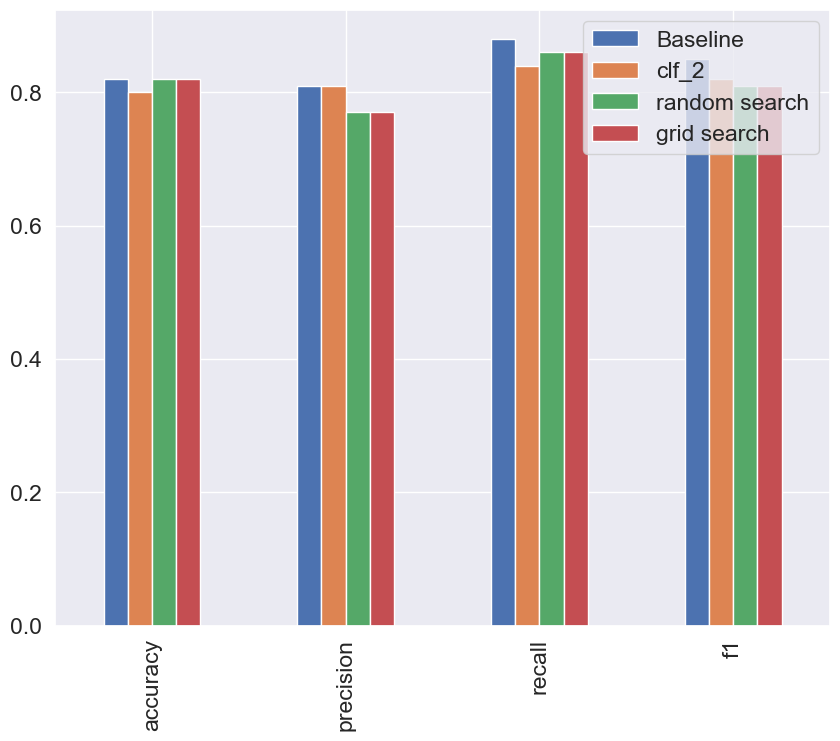

In [465]:
compare_metrics = pd.DataFrame({"Baseline":baseline_metrics,
                               "clf_2":clf2_metrics,
                               "random search":rs_metric,
                               "grid search":gs_metris})

compare_metrics.plot.bar(figsize=(10,8))

# Saving and loading a trained model

Two ways to do it
1. Pickle
2. joblib

### 1. Pickle

In [467]:
# save an existing an model to file
import pickle

pickle.dump(gs_clf,open("gs-random-forest-model1.pkl","wb"))

C:\Users\Savya Sapkota\AppData\Local\Temp\ipykernel_11968\518010963.py:4: ResourceWarning: unclosed file <_io.BufferedWriter name='gs-random-forest-model1.pkl'>
  pickle.dump(gs_clf,open("gs-random-forest-model1.pkl","wb"))


In [468]:
# load the saved model
loaded_pickle_model = pickle.load(open("gs-random-forest-model1.pkl","rb"))

C:\Users\Savya Sapkota\AppData\Local\Temp\ipykernel_11968\1759409220.py:2: ResourceWarning: unclosed file <_io.BufferedReader name='gs-random-forest-model1.pkl'>
  loaded_pickle_model = pickle.load(open("gs-random-forest-model1.pkl","rb"))


In [470]:
pickle_y_preds = loaded_pickle_model.predict(X_test)
evaluate_preds(Y_test,pickle_y_preds)

Accuracy Score: 81.97%
Precision Score: 0.77
Recall Score: 0.86
F1 Score: 0.81


{'accuracy': 0.82, 'precision': 0.77, 'recall': 0.86, 'f1': 0.81}

# 2. Joblib

In [471]:
from joblib import dump, load

# save the model
dump(gs_clf,filename="gs-randomforest-model1.joblib")

['gs-randomforest-model1.joblib']

In [472]:
# load model
gs_joblib = load(filename="gs-randomforest-model1.joblib")

In [474]:
gs_joblib_y_preds = gs_joblib.predict(X_test)
evaluate_preds(Y_test,gs_joblib_y_preds)

Accuracy Score: 81.97%
Precision Score: 0.77
Recall Score: 0.86
F1 Score: 0.81


{'accuracy': 0.82, 'precision': 0.77, 'recall': 0.86, 'f1': 0.81}

# 7. Putting it all together

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("car-sales-extended-missing-data.csv")
data.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [3]:
data.dtypes

Make              object
Colour            object
Odometer (KM)    float64
Doors            float64
Price            float64
dtype: object

In [4]:
data.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

### Steps we want to do
1. fill missing data
2. convert data to numbers
3. Build a model on data

In [6]:
# Getting data Ready

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Modelling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

# setup the random seed
np.random.seed(42)

# Import the data and drop the rows with missing rows
data = pd.read_csv("car-sales-extended-missing-data.csv")
data = data.dropna(subset=["Price"])

# Define different features and transformet pipeline
categorical_features = ["Make","Colour"]
categorical_transformer  = Pipeline(steps = [("imputer",SimpleImputer(strategy="constant",fill_value="missing")),
                                             ("one_hot",OneHotEncoder(handle_unknown="ignore"))])

door_feature = ["Doors"]
door_transformer = Pipeline(steps = [("imputer",SimpleImputer(strategy="constant",fill_value=4))])

numeric_features = ["Odometer (KM)"]
numeric_transformer = Pipeline(steps = [("imputer",SimpleImputer(strategy="mean"))])

# setup preprocessing steps (fill missing valus and conver to numbers)
preprocessor = ColumnTransformer(transformers=[("cat",categorical_transformer,categorical_features),
                                               ("door",door_transformer,door_feature),
                                               ("num",numeric_transformer,numeric_features)])

# create a preprocessing and modelling pipeline
model = Pipeline(steps=[("preprocessor",preprocessor),
                       ("model",RandomForestRegressor())])

#split the data
X = data.drop("Price",axis=1)
Y = data["Price"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

# fit and  score a model
model.fit(X_train,Y_train)
model.score(X_test,Y_test)




0.22188417408787875

In [8]:
# Use Grid search cv with our regressin pipeline
from sklearn.model_selection import GridSearchCV
pipe_grid = {
    "preprocessor__num__imputer__strategy":["mean","median"],
    "model__n_estimators":[100,1000],
    "model__max_depth":[None,5],
    "model__max_features":["log2"],
    "model__min_samples_split":[2,4]
}

gs_model = GridSearchCV(model,pipe_grid,cv=5,verbose=2)
gs_model.fit(X_train,Y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_split=2, model__n_estimators=100, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=log2, model__min_sampl

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5], 'model__max_features': ['log2'], 'model__min_samples_split': [2, 4], 'model__n_estimators': [100, 1000], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [9]:
gs_model.score(X_test,Y_test)

0.2848784564026805